In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Stil
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [3]:
# ─── 1. VERİ YÜKLEME ───────────────────────────────────────────────────────────
df = pd.read_csv('Stars.csv')
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())
print("Class distribution:\n", df['Type'].value_counts())

type_names = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
df['Type_Name'] = df['Type'].map(type_names)

# Color normalization
df['Color'] = df['Color'].str.strip().str.lower()
color_map = {
    'blue-white': 'Blue-White', 'blue white': 'Blue-White',
    'blue': 'Blue', 'red': 'Red', 'white': 'White',
    'yellow-white': 'Yellow-White', 'yellowish white': 'Yellow-White',
    'yellow white': 'Yellow-White', 'whitish': 'White',
    'white-yellow': 'Yellow-White', 'pale yellow orange': 'Yellow-Orange',
    'yellowish': 'Yellow-Orange', 'orange-red': 'Orange-Red',
    'orange': 'Orange', 'yellow': 'Yellow'
}
df['Color_Clean'] = df['Color'].map(lambda x: color_map.get(x, 'Other'))

print("\nColor distribution after cleaning:\n", df['Color_Clean'].value_counts())

=== DATASET OVERVIEW ===
Shape: (240, 7)
Temperature         int64
L                 float64
R                 float64
A_M               float64
Color              object
Spectral_Class     object
Type                int64
dtype: object
   Temperature         L       R    A_M Color Spectral_Class  Type
0         3068  0.002400  0.1700  16.12   Red              M     0
1         3042  0.000500  0.1542  16.60   Red              M     0
2         2600  0.000300  0.1020  18.70   Red              M     0
3         2800  0.000200  0.1600  16.65   Red              M     0
4         1939  0.000138  0.1030  20.06   Red              M     0
        Temperature              L            R         A_M        Type
count    240.000000     240.000000   240.000000  240.000000  240.000000
mean   10497.462500  107188.361635   237.157781    4.382396    2.500000
std     9552.425037  179432.244940   517.155763   10.532512    1.711394
min     1939.000000       0.000080     0.008400  -11.920000    0.000000
2

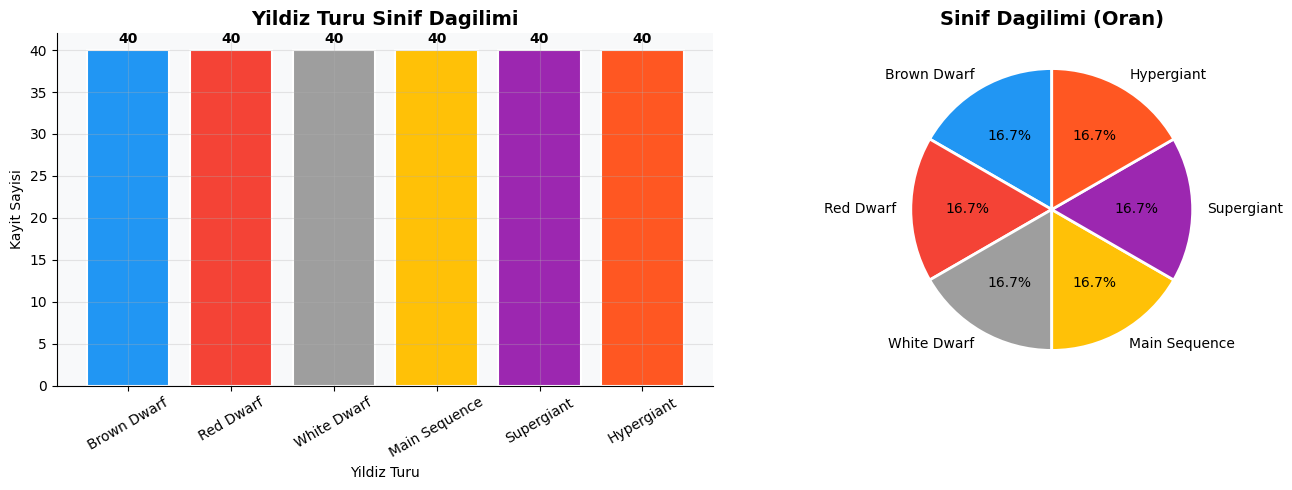

Fig 1 saved.


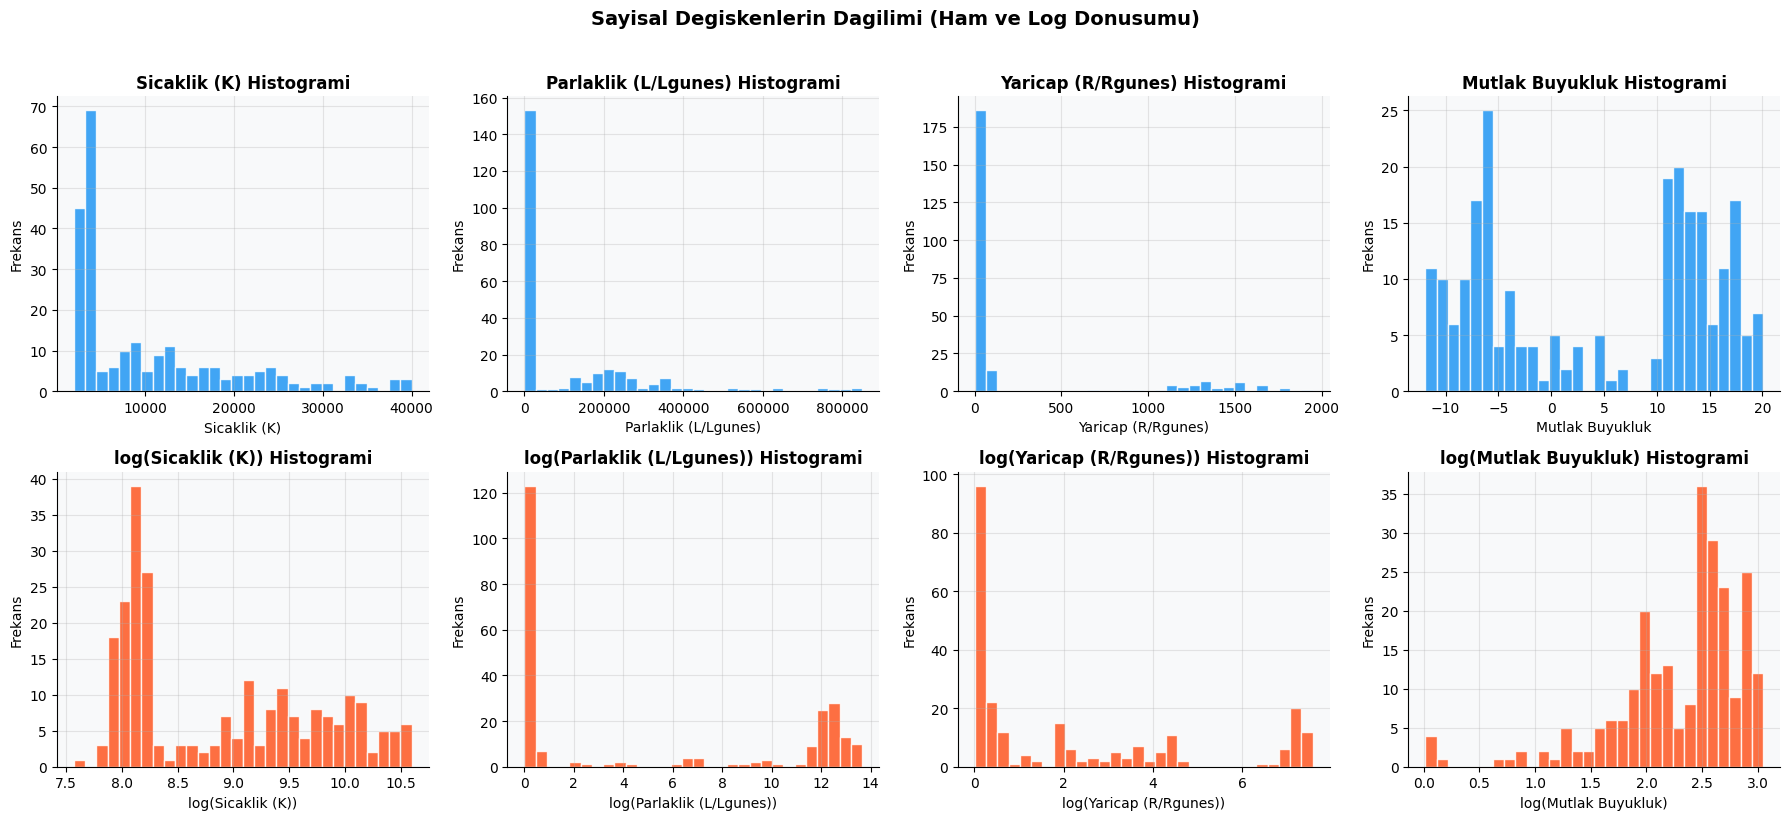

Fig 2 saved.


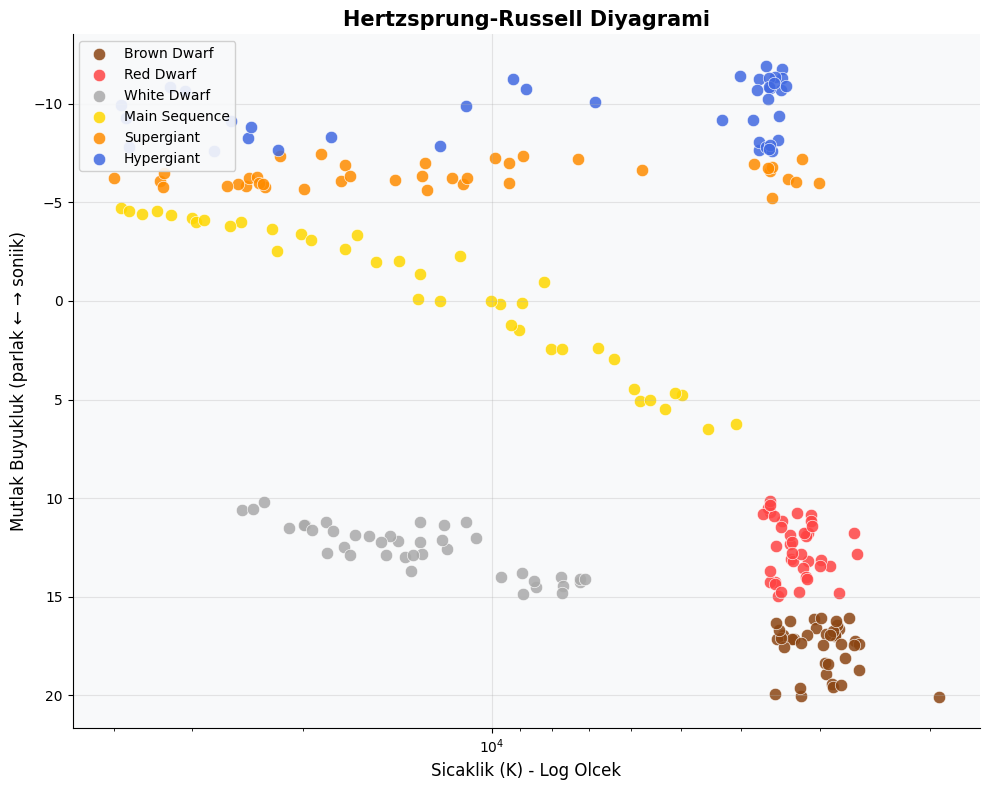

Fig 3 saved.


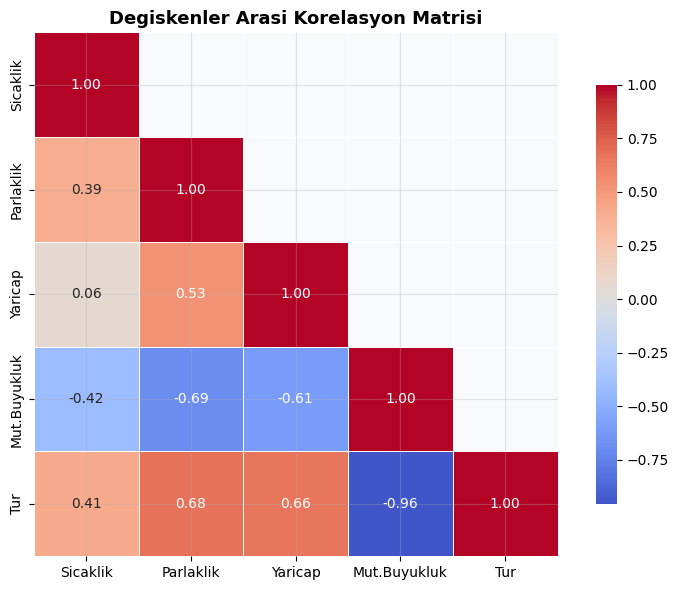

Fig 4 saved.


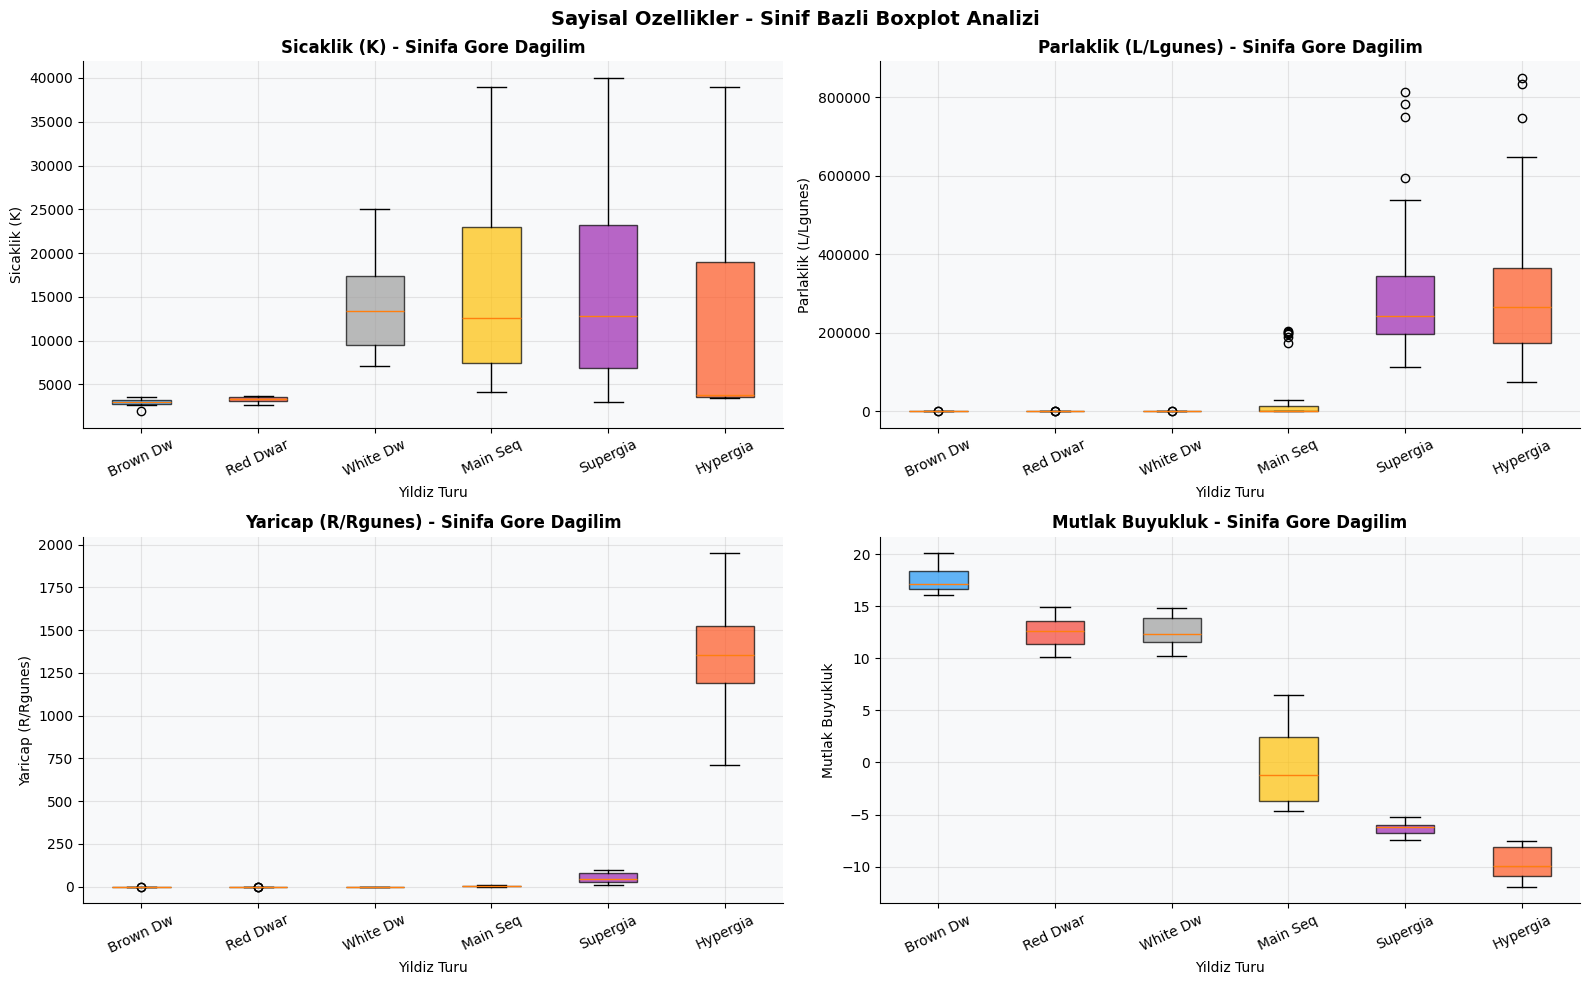

Fig 5 saved.


In [4]:
# ─── 2. EDA GRAFİKLERİ ─────────────────────────────────────────────────────────

# Fig 1: Sınıf dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = ['#2196F3', '#F44336', '#9E9E9E', '#FFC107', '#9C27B0', '#FF5722']
counts = df['Type'].value_counts().sort_index()
bars = axes[0].bar([type_names[i] for i in counts.index], counts.values,
                    color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0].set_title('Yildiz Turu Sinif Dagilimi', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Yildiz Turu')
axes[0].set_ylabel('Kayit Sayisi')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  str(val), ha='center', va='bottom', fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=[type_names[i] for i in counts.index],
    autopct='%1.1f%%', colors=colors_bar, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Sinif Dagilimi (Oran)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved.")

# Fig 2: Sayisal degisken dagilimlari
num_cols = ['Temperature', 'L', 'R', 'A_M']
col_labels = ['Sicaklik (K)', 'Parlaklik (L/Lgunes)', 'Yaricap (R/Rgunes)', 'Mutlak Buyukluk']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (col, label) in enumerate(zip(num_cols, col_labels)):
    axes[0, i].hist(df[col], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{label} Histogrami', fontweight='bold')
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Frekans')
    axes[1, i].hist(np.log1p(df[col].abs()), bins=30, color='#FF5722', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'log({label}) Histogrami', fontweight='bold')
    axes[1, i].set_xlabel(f'log({label})')
    axes[1, i].set_ylabel('Frekans')
plt.suptitle('Sayisal Degiskenlerin Dagilimi (Ham ve Log Donusumu)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Outputs/fig2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 saved.")

# Fig 3: HR Diyagrami (Hertzsprung-Russell)
fig, ax = plt.subplots(figsize=(10, 8))
colors_hr = {0: '#8B4513', 1: '#FF4444', 2: '#AAAAAA', 3: '#FFD700', 4: '#FF8C00', 5: '#4169E1'}
for star_type in sorted(df['Type'].unique()):
    subset = df[df['Type'] == star_type]
    ax.scatter(subset['Temperature'], subset['A_M'],
               c=colors_hr[star_type], label=type_names[star_type],
               alpha=0.85, s=80, edgecolors='white', linewidths=0.5)
ax.set_xscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('Sicaklik (K) - Log Olcek', fontsize=12)
ax.set_ylabel('Mutlak Buyukluk (parlak ← → soniik)', fontsize=12)
ax.set_title('Hertzsprung-Russell Diyagrami', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('Outputs/fig3_hr_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 saved.")

# Fig 4: Korelasyon matrisi (sayisal)
fig, ax = plt.subplots(figsize=(8, 6))
corr_df = df[['Temperature', 'L', 'R', 'A_M', 'Type']].copy()
corr_df.columns = ['Sicaklik', 'Parlaklik', 'Yaricap', 'Mut.Buyukluk', 'Tur']
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Degiskenler Arasi Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 saved.")

# Fig 5: Boxplot - her sinif icin sayisal ozellikler
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, label in zip(axes.flatten(), num_cols, col_labels):
    data_by_class = [df[df['Type'] == t][col].values for t in sorted(df['Type'].unique())]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    labels=[type_names[t][:8] for t in sorted(df['Type'].unique())])
    for patch, color in zip(bp['boxes'], colors_bar):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{label} - Sinifa Gore Dagilim', fontweight='bold')
    ax.set_xlabel('Yildiz Turu')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('Sayisal Ozellikler - Sinif Bazli Boxplot Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 saved.")

In [5]:
# ─── 3. VERİ ÖN İŞLEME ─────────────────────────────────────────────────────────
le_color = LabelEncoder()
le_spectral = LabelEncoder()
df_processed = df.copy()
df_processed['Color_Enc'] = le_color.fit_transform(df_processed['Color_Clean'])
df_processed['Spectral_Enc'] = le_spectral.fit_transform(df_processed['Spectral_Class'])

X = df_processed[['Temperature', 'L', 'R', 'A_M', 'Color_Enc', 'Spectral_Enc']]
y = df_processed['Type']

# Train-test split (ölçeklendirmeden ÖNCE — veri sızıntısını önler)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaler sadece train üzerinde fit edilir, test'e transform uygulanır
# DÜZELTME: X_scaled = scaler.fit_transform(X) satırı KALDIRILDI.
# Tüm X üzerinde scaler.fit() çağırmak veri sızıntısıdır (test bilgisi eğitime sızar).
# CV pipeline'ları kendi içlerinde scaler fit eder, bu satıra gerek yoktu.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)

print("\nFeature statistics after scaling (train set):")
print(X_train.describe().round(3))
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Feature statistics after scaling (train set):
       Temperature        L        R      A_M  Color_Enc  Spectral_Enc
count      192.000  192.000  192.000  192.000    192.000       192.000
mean         0.000    0.000    0.000    0.000      0.000         0.000
std          1.003    1.003    1.003    1.003      1.003         1.003
min         -0.904   -0.589   -0.460   -1.558     -1.383        -1.803
25%         -0.745   -0.589   -0.460   -1.015     -0.906        -1.320
50%         -0.512   -0.589   -0.459    0.379      0.524         0.611
75%          0.532    0.498   -0.365    0.876      0.524         0.611
max          3.346    4.402    3.354    1.503      1.954         1.094

Train: (192, 6), Test: (48, 6)


In [6]:
# ─── 4. MODEL EĞİTİMİ ─────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- KNN ---
# DÜZELTME: K aralığı 3'ten başlıyor.
# K=1, matematiksel olarak her zaman %100 train accuracy verir
# (her nokta kendi en yakın komşusudur). Bu overfitting görüntüsü yaratır
# ve gerçek genelleştirme performansını gizler.
k_scores = []
for k in range(3, 21):
    knn_tmp = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(knn_tmp, X, y, cv=cv, scoring='accuracy').mean()
    k_scores.append(score)
best_k = np.argmax(k_scores) + 3  # +3 çünkü range(3,21)'den başladı
print(f"\nBest K for KNN: {best_k} (CV Accuracy: {max(k_scores):.4f})")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))])
knn_cv = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='accuracy')

# --- Decision Tree ---
depth_scores = []
for d in range(2, 20):
    dt_tmp = Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(max_depth=d, random_state=42))])
    score = cross_val_score(dt_tmp, X, y, cv=cv, scoring='accuracy').mean()
    depth_scores.append(score)
best_depth = np.argmax(depth_scores) + 2
print(f"Best Depth for DT: {best_depth} (CV Accuracy: {max(depth_scores):.4f})")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42, min_samples_split=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_pipeline = Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(max_depth=best_depth, random_state=42, min_samples_split=4))])
dt_cv = cross_val_score(dt_pipeline, X, y, cv=cv, scoring='accuracy')

# --- Random Forest ---
# DÜZELTME: oob_score=True eklendi.
# max_depth=None küçük+temiz veri setlerinde %100 train accuracy verebilir;
# OOB skoru, test seti kullanmadan ek bir tarafsız doğrulama sağlar.
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None,
                             min_samples_leaf=2, oob_score=True)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"RF OOB Score (tarafsız ic dogrulama): {rf.oob_score_:.4f}")
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None, min_samples_leaf=2))])
rf_cv = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='accuracy')


Best K for KNN: 4 (CV Accuracy: 0.9708)
Best Depth for DT: 4 (CV Accuracy: 0.9958)
RF OOB Score (tarafsız ic dogrulama): 0.9948


In [7]:
# ─── 5. METRİKLER ─────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_train_true, y_train_pred, cv_scores, name):
    acc  = accuracy_score(y_true, y_pred)
    tr_acc = accuracy_score(y_train_true, y_train_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    gap  = tr_acc - acc  # overfitting göstergesi
    print(f"\n=== {name} ===")
    print(f"Train Accuracy: {tr_acc:.4f}  |  Test Accuracy: {acc:.4f}  |  Fark (gap): {gap:.4f}")
    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_true, y_pred, target_names=list(type_names.values())))
    return {'Model': name, 'Train Accuracy': tr_acc, 'Test Accuracy': acc,
            'Gap (Train-Test)': gap, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1,
            'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()}

results = []
results.append(get_metrics(y_test, y_pred_knn, y_train, knn.predict(X_train), knn_cv, f'KNN (k={best_k})'))
results.append(get_metrics(y_test, y_pred_dt,  y_train, dt.predict(X_train),  dt_cv,  f'Karar Agaci (depth={best_depth})'))
results.append(get_metrics(y_test, y_pred_rf,  y_train, rf.predict(X_train),  rf_cv,  'Random Forest (100 agac)'))

results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df[['Model','Train Accuracy','Test Accuracy','Gap (Train-Test)','F1 Score','CV Mean','CV Std']].to_string())


=== KNN (k=4) ===
Train Accuracy: 0.9740  |  Test Accuracy: 0.9375  |  Fark (gap): 0.0365
Precision: 0.9429, Recall: 0.9375, F1: 0.9370
CV Accuracy: 0.9708 ± 0.0167
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00         8
    Red Dwarf       1.00      1.00      1.00         8
  White Dwarf       1.00      1.00      1.00         8
Main Sequence       0.80      1.00      0.89         8
   Supergiant       0.86      0.75      0.80         8
   Hypergiant       1.00      0.88      0.93         8

     accuracy                           0.94        48
    macro avg       0.94      0.94      0.94        48
 weighted avg       0.94      0.94      0.94        48


=== Karar Agaci (depth=4) ===
Train Accuracy: 1.0000  |  Test Accuracy: 1.0000  |  Fark (gap): 0.0000
Precision: 1.0000, Recall: 1.0000, F1: 1.0000
CV Accuracy: 0.9958 ± 0.0083
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00   

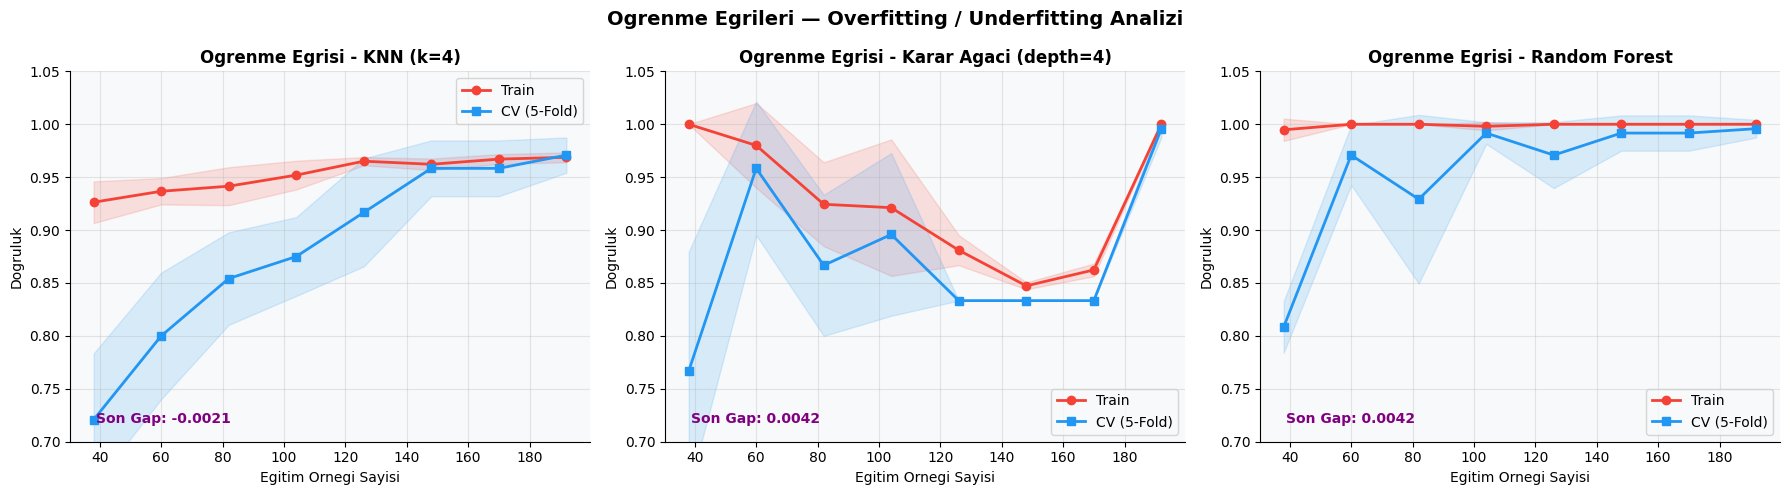

Fig 10 (Learning Curves) saved.


In [8]:
# ─── 6b. ÖĞRENME EĞRİSİ — Overfitting / Underfitting Analizi ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_lc = [
    (Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))]), f'KNN (k={best_k})'),
    (Pipeline([('sc', StandardScaler()), ('dt', DecisionTreeClassifier(max_depth=best_depth, random_state=42))]), f'Karar Agaci (depth={best_depth})'),
    (Pipeline([('sc', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=100, random_state=42, min_samples_leaf=2))]), 'Random Forest'),
]
train_sizes_pct = np.linspace(0.2, 1.0, 8)
for ax, (pipe, name) in zip(axes, models_lc):
    tr_sizes, tr_scores, cv_scores_lc = learning_curve(
        pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
        train_sizes=train_sizes_pct, scoring='accuracy', n_jobs=1)
    tr_mean, tr_std = tr_scores.mean(axis=1), tr_scores.std(axis=1)
    cv_mean, cv_std = cv_scores_lc.mean(axis=1), cv_scores_lc.std(axis=1)
    ax.plot(tr_sizes, tr_mean, 'o-', color='#F44336', label='Train', linewidth=2)
    ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#F44336')
    ax.plot(tr_sizes, cv_mean, 's-', color='#2196F3', label='CV (5-Fold)', linewidth=2)
    ax.fill_between(tr_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color='#2196F3')
    ax.set_title(f'Ogrenme Egrisi - {name}', fontweight='bold')
    ax.set_xlabel('Egitim Ornegi Sayisi')
    ax.set_ylabel('Dogruluk')
    ax.set_ylim(0.7, 1.05)
    ax.legend()
    gap = tr_mean[-1] - cv_mean[-1]
    ax.text(0.05, 0.05, f'Son Gap: {gap:.4f}', transform=ax.transAxes,
            fontsize=10, color='purple', fontweight='bold')
plt.suptitle('Ogrenme Egrileri — Overfitting / Underfitting Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig10_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 10 (Learning Curves) saved.")

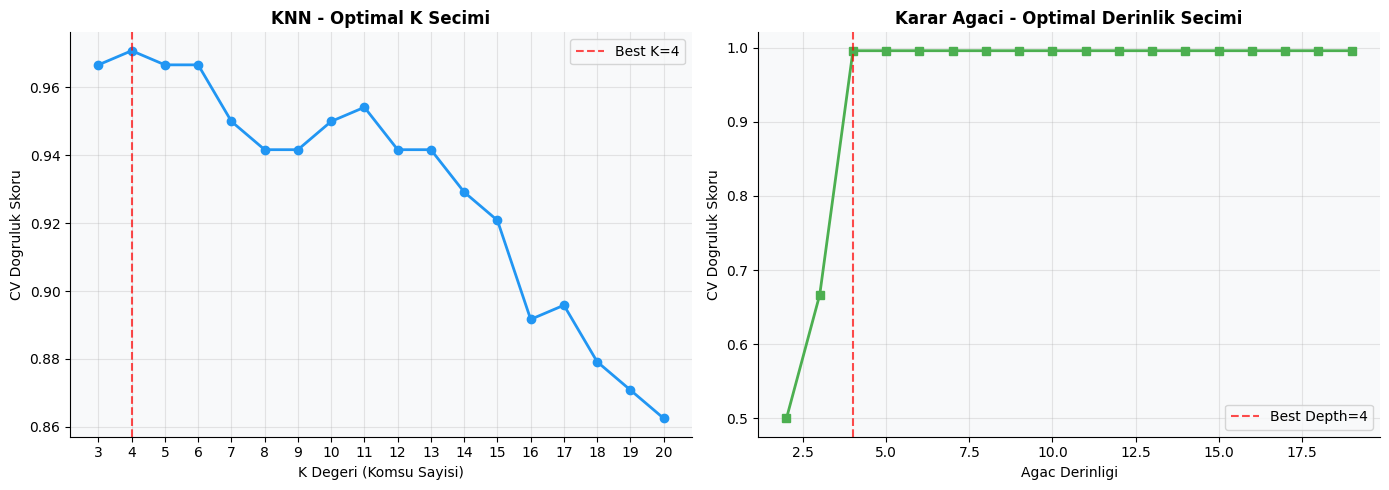

Fig 6 saved.


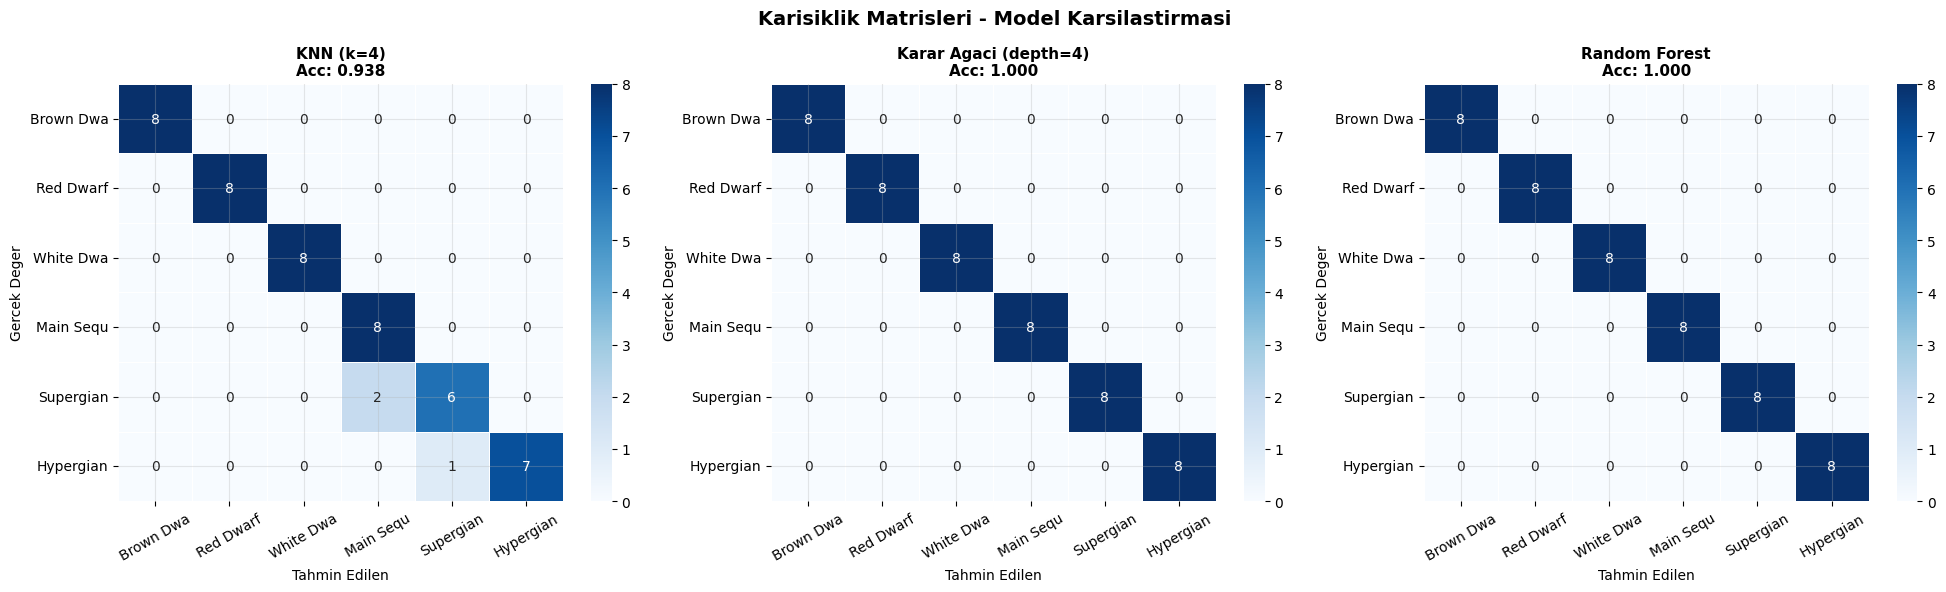

Fig 7 saved.


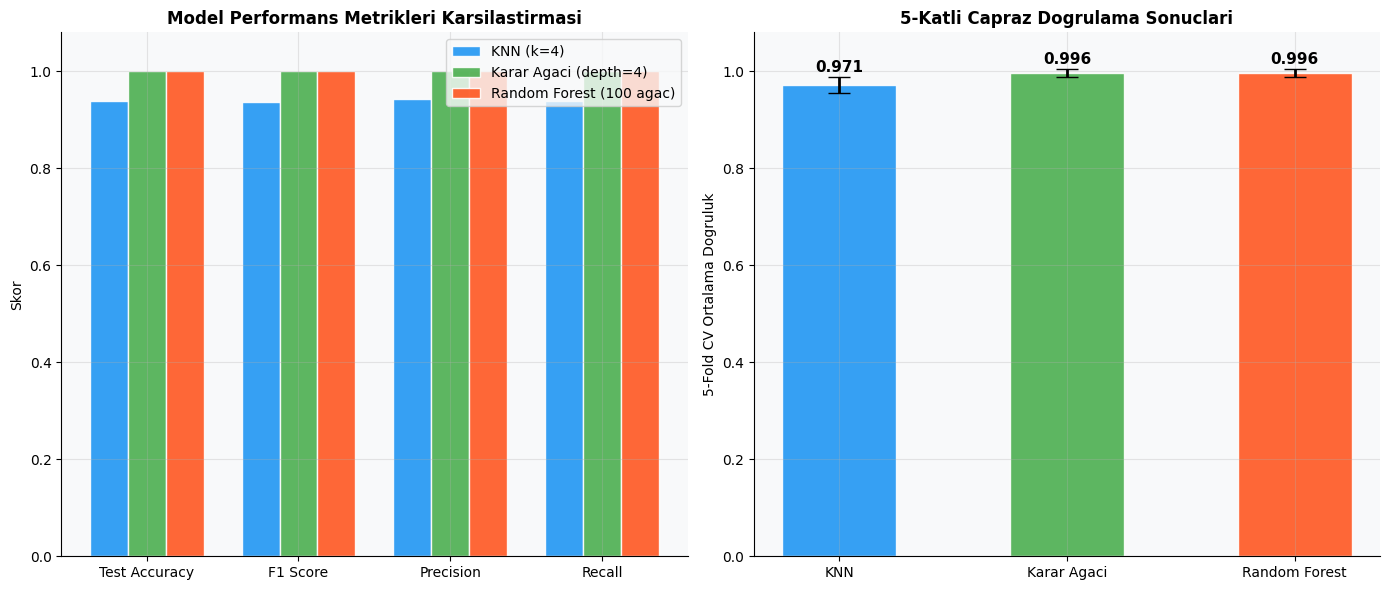

Fig 8 saved.


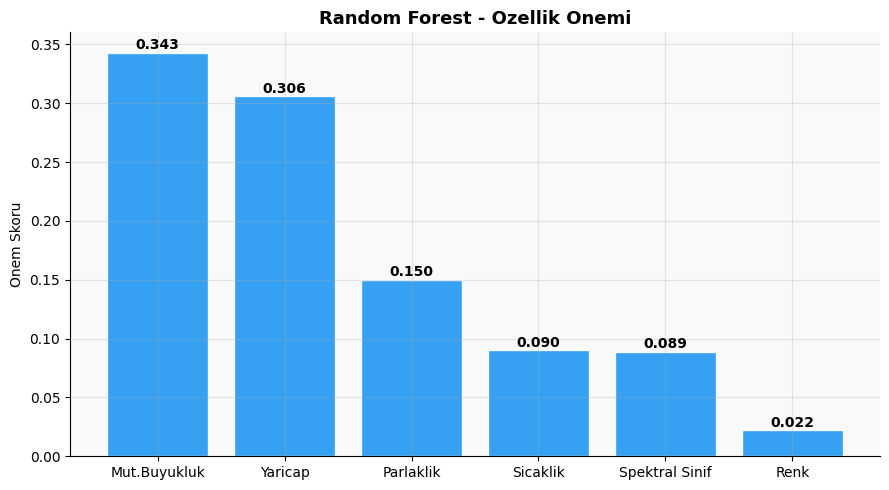

Fig 9 saved.

=== ALL DONE ===
Best K: 4
Best Depth: 4
                   Model  Test Accuracy  F1 Score  CV Mean   CV Std
               KNN (k=4)         0.9375  0.937037 0.970833 0.016667
   Karar Agaci (depth=4)         1.0000  1.000000 0.995833 0.008333
Random Forest (100 agac)         1.0000  1.000000 0.995833 0.008333


In [9]:
# ─── 6. GÖRSEL: K optimizasyonu + Confusion Matrices ─────────────────────────

# Fig 6: K ve depth optimizasyonu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(3, 21), k_scores, 'o-', color='#2196F3', linewidth=2, markersize=6)
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[0].set_xlabel('K Degeri (Komsu Sayisi)')
axes[0].set_ylabel('CV Dogruluk Skoru')
axes[0].set_title('KNN - Optimal K Secimi', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(3, 21))

axes[1].plot(range(2, 20), depth_scores, 's-', color='#4CAF50', linewidth=2, markersize=6)
axes[1].axvline(x=best_depth, color='red', linestyle='--', alpha=0.7, label=f'Best Depth={best_depth}')
axes[1].set_xlabel('Agac Derinligi')
axes[1].set_ylabel('CV Dogruluk Skoru')
axes[1].set_title('Karar Agaci - Optimal Derinlik Secimi', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('Outputs/fig6_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 6 saved.")

# Fig 7: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_preds = [
    (y_pred_knn, f'KNN (k={best_k})'),
    (y_pred_dt, f'Karar Agaci (depth={best_depth})'),
    (y_pred_rf, 'Random Forest')
]
class_labels = [type_names[i][:9] for i in range(6)]
for ax, (y_pred, name) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f}',
                  fontweight='bold', fontsize=11)
    ax.set_xlabel('Tahmin Edilen')
    ax.set_ylabel('Gercek Deger')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.suptitle('Karisiklik Matrisleri - Model Karsilastirmasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 saved.")

# Fig 8: Model karsilastirma bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics_to_plot = ['Test Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_plot))
width = 0.25
model_colors = ['#2196F3', '#4CAF50', '#FF5722']
for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    bars = axes[0].bar(x + i * width, values, width, label=row['Model'],
                       color=model_colors[i], edgecolor='white', alpha=0.9)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylabel('Skor')
axes[0].set_ylim(0, 1.08)
axes[0].set_title('Model Performans Metrikleri Karsilastirmasi', fontweight='bold')
axes[0].legend()

# CV mean ± std
model_names_short = ['KNN', 'Karar Agaci', 'Random Forest']
cv_means = results_df['CV Mean'].values
cv_stds = results_df['CV Std'].values
bars2 = axes[1].bar(model_names_short, cv_means, color=model_colors,
                     edgecolor='white', alpha=0.9, width=0.5)
axes[1].errorbar(model_names_short, cv_means, yerr=cv_stds,
                  fmt='none', color='black', capsize=8, linewidth=2)
axes[1].set_ylabel('5-Fold CV Ortalama Dogruluk')
axes[1].set_ylim(0, 1.08)
axes[1].set_title('5-Katli Capraz Dogrulama Sonuclari', fontweight='bold')
for bar, mean, std in zip(bars2, cv_means, cv_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + std + 0.01,
                  f'{mean:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('Outputs/fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 8 saved.")

# Fig 9: Feature importance (Random Forest)
fig, ax = plt.subplots(figsize=(9, 5))
feat_names = ['Sicaklik', 'Parlaklik', 'Yaricap', 'Mut.Buyukluk', 'Renk', 'Spektral Sinif']
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
bars = ax.bar([feat_names[i] for i in sorted_idx],
               importances[sorted_idx],
               color='#2196F3', edgecolor='white', alpha=0.9)
ax.set_title('Random Forest - Ozellik Onemi', fontweight='bold', fontsize=13)
ax.set_ylabel('Onem Skoru')
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('Outputs/fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 9 saved.")

print("\n=== ALL DONE ===")
print(f"Best K: {best_k}")
print(f"Best Depth: {best_depth}")
print(results_df[['Model','Test Accuracy','F1 Score','CV Mean','CV Std']].to_string(index=False))
